# Divide-and-conquer Kriging (`NestedKriging`) vs exact Cholesky

## Context

Exact Kriging needs one dense Cholesky factorization of the $n\times n$
correlation matrix $R(\theta)$ per likelihood evaluation — $O(n^3)$ time,
$O(n^2)$ memory. `LLVecchia`/`LLNystrom` (see the sibling notebooks) keep
that cost down by changing *how cheaply the same global likelihood is
evaluated*. `NestedKriging` takes a structurally different route: split
$(X,y)$ into $p$ groups, fit one **exact** submodel per group — cheap,
$O((n/p)^3)$ each, so $O(n^3/p^2)$ total — unify their hyperparameters
into one shared prior, and *aggregate* the $p$ submodel predictions into
a single one at predict time.

$$
\texttt{NestedKriging}(y, X, \texttt{nb\_groups}=p,\ \texttt{aggregation}=\text{"NK"})
$$

This notebook uses the **`NK`** aggregation (Rullière, Durrande, Bachoc &
Chevalier, 2018), the default: it treats the $p$ submodel predictors
$M_i(x)$ as noisy observations of the same underlying $f(x)$ and krige
them, which makes `NK` itself a proper kriging predictor — consistent
variances, and (unlike the cheaper PoE family) it **converges to the
exact predictor as $p\to 1$**. That's the first thing checked below, and
it's also the fallback identity that makes `NestedKriging` a strict
generalization of plain `Kriging` rather than a separate approximation
family.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pylibkriging as lk
import warnings
warnings.filterwarnings('ignore')

np.random.seed(1)
plt.rcParams['figure.figsize'] = (10, 4.5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))


## 1. Running example

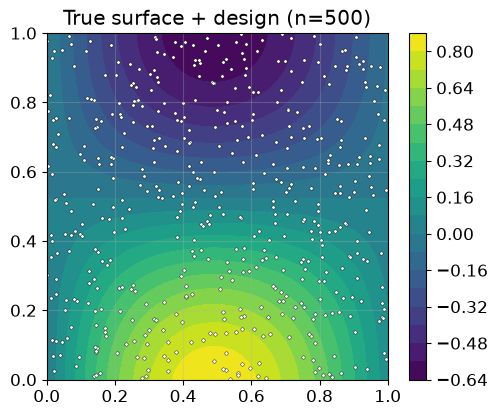

n = 500, 300 held-out test points


In [2]:
def f(x1, x2):
    return np.sin(3 * x1) * np.cos(3 * x2) * np.exp(-0.3 * (x1 + x2))

n = 500
X = np.random.uniform(0, 1, size=(n, 2))
y = f(X[:, 0], X[:, 1]) + np.random.normal(0, 0.03, size=n)

Xt = np.random.uniform(0, 1, size=(300, 2))
yt = f(Xt[:, 0], Xt[:, 1])

grid = np.linspace(0, 1, 80)
G1, G2 = np.meshgrid(grid, grid)
Z_true = f(G1, G2)

fig, ax = plt.subplots(1, 1, figsize=(5.5, 4.5))
c = ax.contourf(G1, G2, Z_true, levels=20, cmap='viridis')
ax.scatter(X[:, 0], X[:, 1], s=6, c='white', edgecolor='k', linewidth=0.3)
ax.set_title(f'True surface + design (n={n})')
plt.colorbar(c, ax=ax)
plt.show()
print(f'n = {n}, {len(Xt)} held-out test points')


## 2. Recap: the exact objective, with a real fit

A real `optim="BFGS(1)"` fit, exactly as you'd run it in practice --
`NestedKriging` below runs its own independent `BFGS(1)` fit too, so any
gap between the two picks up ordinary fit-to-fit $\hat\theta$ variation
on top of whatever the partition/aggregation itself costs in accuracy.

In [3]:
theta0 = np.array([[0.3, 0.3]])

t0 = time.perf_counter()
k_exact = lk.Kriging(y, X, 'matern5_2', regmodel='constant',
                      objective='LL', optim='BFGS(1)', parameters={'theta': theta0})
t_exact = time.perf_counter() - t0

mean_exact, stdev_exact = k_exact.predict(Xt, True, False, False)[:2]
rmse_exact = rmse(mean_exact.ravel(), yt)

print(f'exact fit: {t_exact*1000:7.1f} ms   theta_hat = {k_exact.theta().ravel()}'
      f'   sigma2 = {k_exact.sigma2():.4f}   test RMSE = {rmse_exact:.4f}')


exact fit:   354.4 ms   theta_hat = [0.04871084 0.05499809]   sigma2 = 0.0681   test RMSE = 0.0615


## 3. `NestedKriging` with a single group: an exactness check

With `nb_groups=1` there is exactly one submodel spanning all of $X$, and
`NK` aggregation of a single predictor is the identity -- so this must
reproduce `k_exact`'s predictions, up to the usual floating-point/solver
noise between two independently-run Cholesky factorizations. This is the
same reasoning `Nested.md` documents: `NK` "interpolates the data exactly
... with $p=1$ it reduces to ordinary kriging".

In [4]:
t0 = time.perf_counter()
nk1 = lk.NestedKriging(y, X, 'matern5_2', 1, aggregation='NK', partition='kmeans', seed=1,
                        regmodel='constant', objective='LL', optim='BFGS(1)',
                        parameters={'theta': theta0})
t_nk1 = time.perf_counter() - t0

mean_nk1, stdev_nk1 = nk1.predict(Xt, True)
print(f'nb_groups=1 fit: {t_nk1*1000:7.1f} ms   theta_hat = {nk1.theta().ravel()}')
print(f'max |mean diff|  vs exact = {np.max(np.abs(mean_nk1.ravel()-mean_exact.ravel())):.2e}')
print(f'max |stdev diff| vs exact = {np.max(np.abs(stdev_nk1.ravel()-stdev_exact.ravel())):.2e}')


nb_groups=1 fit:   460.5 ms   theta_hat = [0.04871084 0.05499809]
max |mean diff|  vs exact = 6.52e-08
max |stdev diff| vs exact = 6.67e-04


## 4. Group count $p$: accuracy vs. cost trade-off

More groups means smaller, cheaper submodels ($O((n/p)^3)$ each) but a
coarser aggregate -- `NK` only sees each group's own local fit, so
cross-group correlation is captured only through the shared prior and the
(worst-case $O(q\,n^2)$) cross-covariance terms, not through a joint
factorization the way exact Kriging has it. Each $p$ below gets its own
independent `BFGS(1)` fit (matching §2 in spirit, not sharing its
$\theta$), so -- exactly as in the `LLNystrom` notebook's $k$-sweep --
expect the accuracy-vs-$p$ trend to be noisier / less monotone than a
fixed-$\theta$ sweep would show, since part of what's measured here is
run-to-run MLE variation rather than the aggregation's own error.

In [5]:
p_grid = [1, 2, 4, 8, 16, 32, 64]
mean_diffs, rmses_nk, times_p = [], [], []
for p in p_grid:
    t0 = time.perf_counter()
    nk = lk.NestedKriging(y, X, 'matern5_2', p, aggregation='NK', partition='kmeans', seed=1,
                           regmodel='constant', objective='LL', optim='BFGS(1)',
                           parameters={'theta': theta0})
    times_p.append(time.perf_counter() - t0)
    m_p, s_p = nk.predict(Xt, True)
    mean_diffs.append(np.max(np.abs(m_p.ravel() - mean_exact.ravel())))
    rmses_nk.append(rmse(m_p.ravel(), yt))
    print(f'p={p:3d}   max|mean diff|={mean_diffs[-1]:.2e}   test RMSE={rmses_nk[-1]:.4f}'
          f'   theta_hat={nk.theta().ravel()}   fit time={times_p[-1]*1000:7.1f} ms')


p=  1   max|mean diff|=6.52e-08   test RMSE=0.0615   theta_hat=[0.04871084 0.05499809]   fit time=  445.2 ms


p=  2   max|mean diff|=1.01e-01   test RMSE=0.0608   theta_hat=[0.06186558 0.04633793]   fit time=  300.4 ms


p=  4   max|mean diff|=2.87e-01   test RMSE=0.0944   theta_hat=[0.24784186 0.12038101]   fit time=  184.8 ms


p=  8   max|mean diff|=3.31e-01   test RMSE=0.0609   theta_hat=[0.06307053 0.02540014]   fit time=  138.2 ms
p= 16   max|mean diff|=2.81e-01   test RMSE=0.0703   theta_hat=[0.03814668 0.03336555]   fit time=   76.3 ms


p= 32   max|mean diff|=4.26e-01   test RMSE=0.0948   theta_hat=[0.029584   0.02857288]   fit time=   83.5 ms


p= 64   max|mean diff|=2.49e-01   test RMSE=0.0308   theta_hat=[0.70194954 0.45096595]   fit time=   60.5 ms


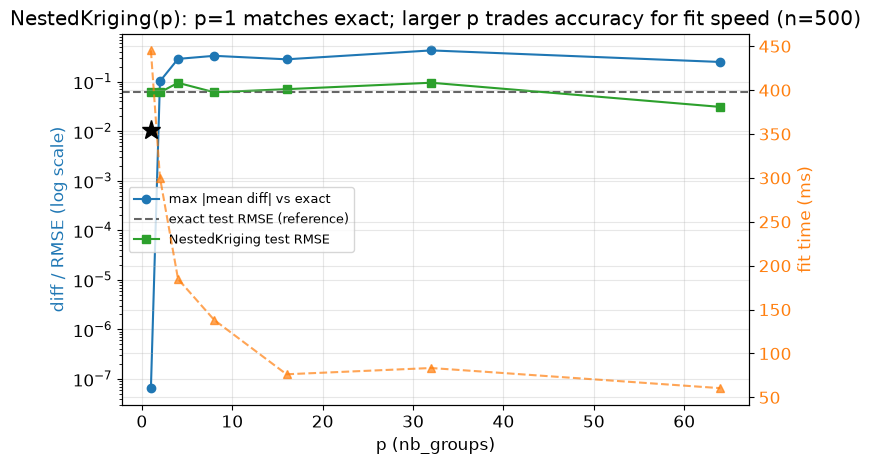

In [6]:
fig, ax1 = plt.subplots(figsize=(8, 4.8))
ax1.semilogy(p_grid, np.array(mean_diffs) + 1e-16, 'o-', color='C0', label='max |mean diff| vs exact')
ax1.axhline(rmse_exact, color='k', ls='--', alpha=0.6, label='exact test RMSE (reference)')
ax1.plot(p_grid, rmses_nk, 's-', color='C2', label='NestedKriging test RMSE')
ax1.set_xlabel('p (nb_groups)')
ax1.set_ylabel('diff / RMSE (log scale)', color='C0')
ax1.legend(loc='center left', fontsize=9)
ax2 = ax1.twinx()
ax2.plot(p_grid, np.array(times_p) * 1000, '^--', color='C1', alpha=0.7)
ax2.plot([1], [t_exact * 1000], 'k*', markersize=14)
ax2.set_ylabel('fit time (ms)', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')
ax1.set_title(f'NestedKriging(p): p=1 matches exact; larger p trades accuracy for fit speed (n={n})')
plt.tight_layout()
plt.show()


## 5. Where the payoff shows: fit time vs. $n$

Real independent `optim="BFGS(1)"` fits again -- the actual end-to-end
cost including however many BFGS iterations each side's optimizer needed.
Groups are sized to keep each submodel around 100 points
($p\approx n/100$), the same divide-and-conquer regime `bench-nestedkriging`
uses.

In [7]:
n_values = [150, 300, 600, 1200, 2400, 4800]
t_exact_n, t_nested_n = [], []

for nn in n_values:
    np.random.seed(1)
    Xn = np.random.uniform(0, 1, size=(nn, 2))
    yn = f(Xn[:, 0], Xn[:, 1]) + np.random.normal(0, 0.03, size=nn)
    p_n = max(2, (nn + 99) // 100)

    t0 = time.perf_counter()
    lk.Kriging(yn, Xn, 'matern5_2', regmodel='constant',
               objective='LL', optim='BFGS(1)', parameters={'theta': theta0})
    t_exact_n.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    lk.NestedKriging(yn, Xn, 'matern5_2', p_n, aggregation='NK', partition='kmeans', seed=1,
                      regmodel='constant', objective='LL', optim='BFGS(1)',
                      parameters={'theta': theta0})
    t_nested_n.append(time.perf_counter() - t0)

    print(f'n={nn:5d}  p={p_n:3d}   exact: {t_exact_n[-1]:7.2f} s   NestedKriging: {t_nested_n[-1]:6.2f} s'
          f'   speedup: {t_exact_n[-1]/t_nested_n[-1]:.1f}x')


n=  150  p=  2   exact:    0.03 s   NestedKriging:   0.02 s   speedup: 1.5x


n=  300  p=  3   exact:    0.17 s   NestedKriging:   0.07 s   speedup: 2.4x
n=  600  p=  6   exact:    0.98 s   NestedKriging:   0.12 s   speedup: 8.1x


n= 1200  p= 12   exact:    9.47 s   NestedKriging:   0.43 s   speedup: 22.0x


n= 2400  p= 24   exact:   15.87 s   NestedKriging:   1.68 s   speedup: 9.5x


n= 4800  p= 48   exact:   51.10 s   NestedKriging:   2.90 s   speedup: 17.6x


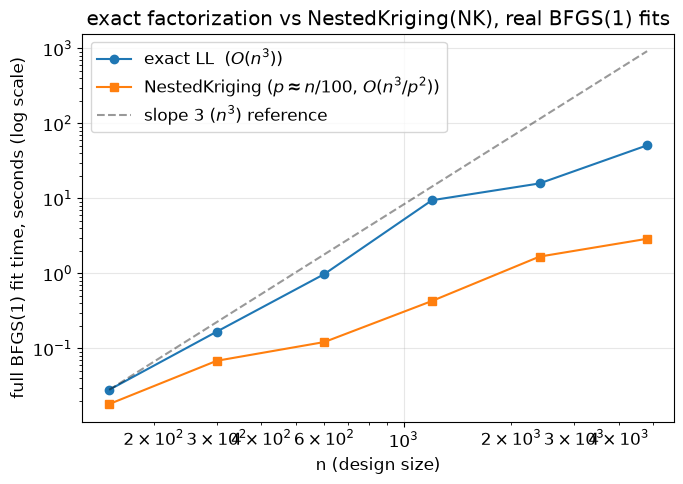

speedups are noisy fit-to-fit (independent BFGS iteration counts on each side),
but the growth-rate gap (roughly n^3 vs its p^2-divided cousin) dominates for large n.


In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(n_values, t_exact_n, 'o-', label='exact LL  ($O(n^3)$)')
ax.loglog(n_values, t_nested_n, 's-', label='NestedKriging ($p\\approx n/100$, $O(n^3/p^2)$)')

n_arr = np.array(n_values, dtype=float)
ax.loglog(n_arr, t_exact_n[0] * (n_arr / n_arr[0])**3, 'k--', alpha=0.4, label='slope 3 ($n^3$) reference')

ax.set_xlabel('n (design size)')
ax.set_ylabel('full BFGS(1) fit time, seconds (log scale)')
ax.set_title('exact factorization vs NestedKriging(NK), real BFGS(1) fits')
ax.legend()
plt.tight_layout()
plt.show()

print('speedups are noisy fit-to-fit (independent BFGS iteration counts on each side),')
print('but the growth-rate gap (roughly n^3 vs its p^2-divided cousin) dominates for large n.')


## Practical guidance

- `NestedKriging`'s submodels are **exact** Kriging fits -- unlike
  `LLVecchia`/`LLNystrom`, nothing about the divide step is
  dimension-sensitive, so it degrades gracefully in higher $d$ (see
  [Scalability.md](Scalability.md)). The trade-off moves to *predict*
  cost instead: `NK` aggregation is $O(q\,n^2)$ worst case (parallelized
  over the $p(p-1)/2$ group pairs), so for large $q$ the cheaper PoE
  family (`aggregation="PoE"/"gPoE"/"BCM"/"rBCM"`, $O(q\,n^2/p)$) may be
  worth trading `NK`'s exact-in-the-limit consistency for -- see
  [Nested.md](Nested.md) §Aggregation.
- `NK` requires a **`"constant"` trend** (simple-kriging theory); the
  PoE family works with any trend.
- As §4 shows, more groups is not free: it buys fit speed but the
  aggregate accuracy degrades, since `NK` only combines groups through
  the shared prior and pairwise cross-covariances, not a joint
  factorization. Pick $p$ as small as the fit-time budget allows rather
  than as large as possible.
- It combines with `objective="LLVecchia(m)"` for the *common-prior* fit
  itself (one global light-Vecchia estimate of $(\theta,\sigma^2,\beta)$
  instead of averaging $p$ local MLEs) -- see [Nested.md](Nested.md)'s
  "Combination with the Vecchia objective" section. `subsetOfData` can
  also be applied first if losing some data outright is acceptable
  before an even-cheaper partition.

## References

- Rullière, D., Durrande, N., Bachoc, F., & Chevalier, C. (2018).
  *Nested Kriging predictions for datasets with a large number of
  observations*. Statistics and Computing, 28(4), 849-867.
- Deisenroth, M. P., & Ng, J. W. (2015). *Distributed Gaussian
  Processes*. Proceedings of ICML 2015 (PoE/BCM/rBCM aggregation).

See also [Nested.md](Nested.md) for the full API reference, and
[Scalability.md](Scalability.md) for how `NestedKriging` compares to
`LLVecchia`, `LLNystrom` and `subsetOfData`.